In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              RandomForestClassifier)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [5]:
student_df = pd.read_csv("C:\\Users\\HP\\Desktop\\labsheet mca\\student-mat.csv", sep=";")
print("Shape:", student_df.shape)
print(student_df.head())

Shape: (395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [6]:
student_df.info()
print("Missing values:", student_df.isnull().sum().sum())
print("Duplicates:", student_df.duplicated().sum())
print(student_df.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [7]:
student_df = student_df.rename(columns={
    "absences": "absences_count",           # attendance
    "G1": "internal_marks_g1",              # internal marks
    "G2": "previous_result_g2",             # previous semester result
    "studytime": "weekly_study_time_band",  # study hours
    "G3": "final_grade",                    # target
})
student_df = student_df.drop_duplicates().dropna().reset_index(drop=True)
print("After cleaning:", student_df.shape)

After cleaning: (395, 33)


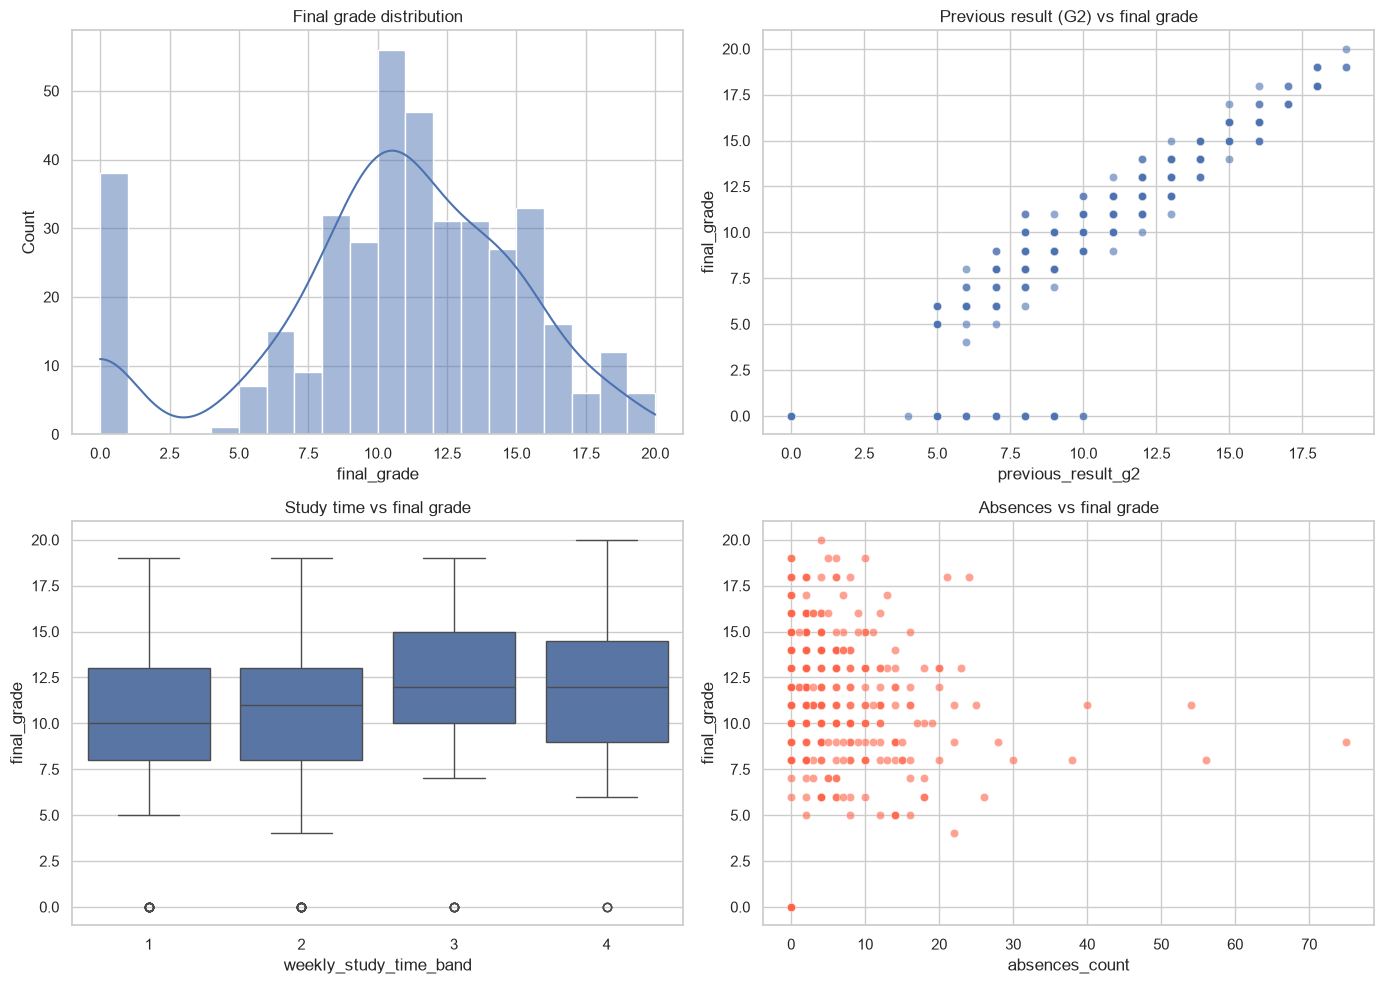

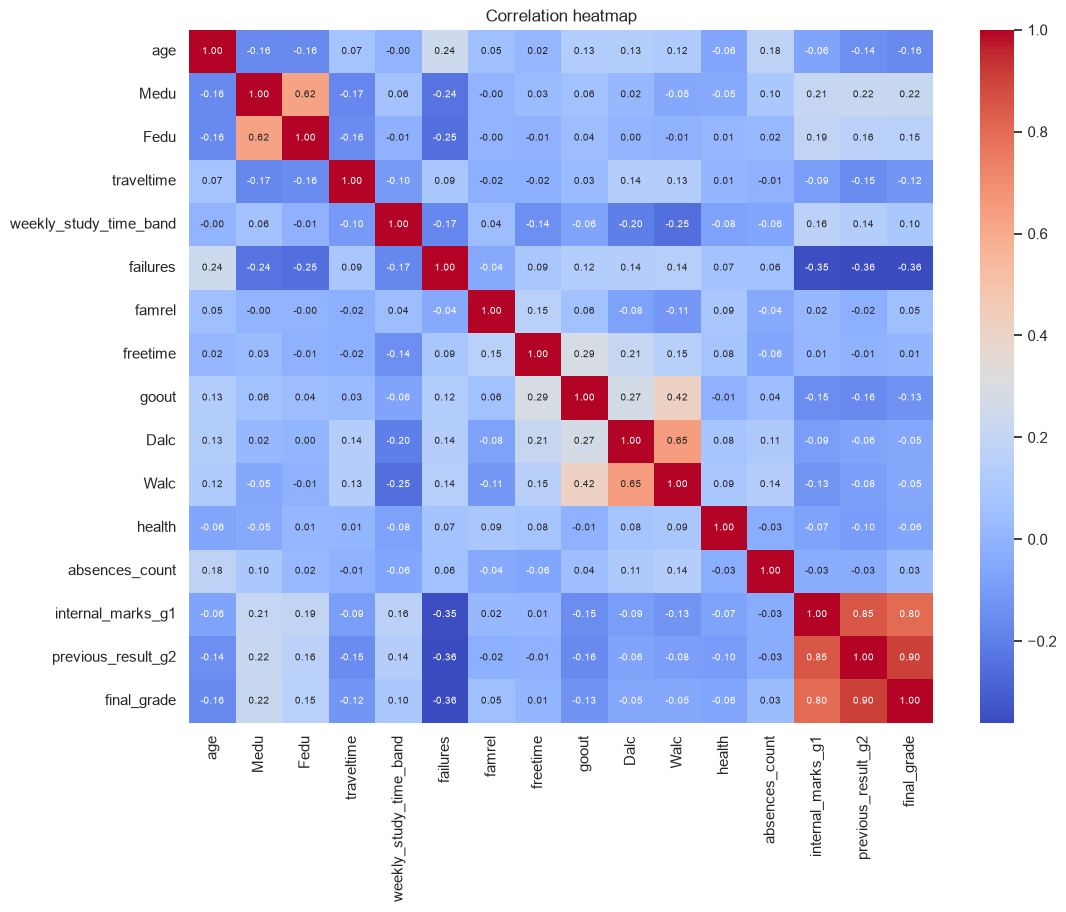

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(student_df["final_grade"], bins=20, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Final grade distribution")
sns.scatterplot(data=student_df, x="previous_result_g2", y="final_grade",
                ax=axes[0, 1], alpha=0.6)
axes[0, 1].set_title("Previous result (G2) vs final grade")
sns.boxplot(data=student_df, x="weekly_study_time_band", y="final_grade",
            ax=axes[1, 0])
axes[1, 0].set_title("Study time vs final grade")
sns.scatterplot(data=student_df, x="absences_count", y="final_grade",
                ax=axes[1, 1], alpha=0.6, color="tomato")
axes[1, 1].set_title("Absences vs final grade")
plt.tight_layout()
plt.show()

numeric_only = student_df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_only.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            annot_kws={"size": 7})
plt.title("Correlation heatmap")
plt.show()

In [9]:
X_all = student_df.drop(columns=["final_grade"])
y_reg = student_df["final_grade"]

categorical_columns = X_all.select_dtypes(include="object").columns.tolist()
numeric_columns = X_all.select_dtypes(exclude="object").columns.tolist()

def build_preprocessor():
    return ColumnTransformer([
        ("numeric", StandardScaler(), numeric_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ])

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_reg, test_size=0.2, random_state=RANDOM_STATE)

In [10]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
trained_regressors, rows = {}, []
for name, estimator in regression_models.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rows.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2 (test)": r2_score(y_test, pred),
        "R2 (5-fold CV)": cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2").mean(),
    })
    trained_regressors[name] = pipe

results_df = pd.DataFrame(rows).sort_values("R2 (test)", ascending=False).reset_index(drop=True)
print(results_df.round(3))
best_model_name = results_df.loc[0, "Model"]
best_regressor = trained_regressors[best_model_name]
print("Best regression model:", best_model_name)

               Model    MAE   RMSE  R2 (test)  R2 (5-fold CV)
0  Gradient Boosting  1.150  1.982      0.808           0.896
1      Random Forest  1.199  2.011      0.803           0.901
2  Linear Regression  1.647  2.378      0.724           0.826
Best regression model: Gradient Boosting


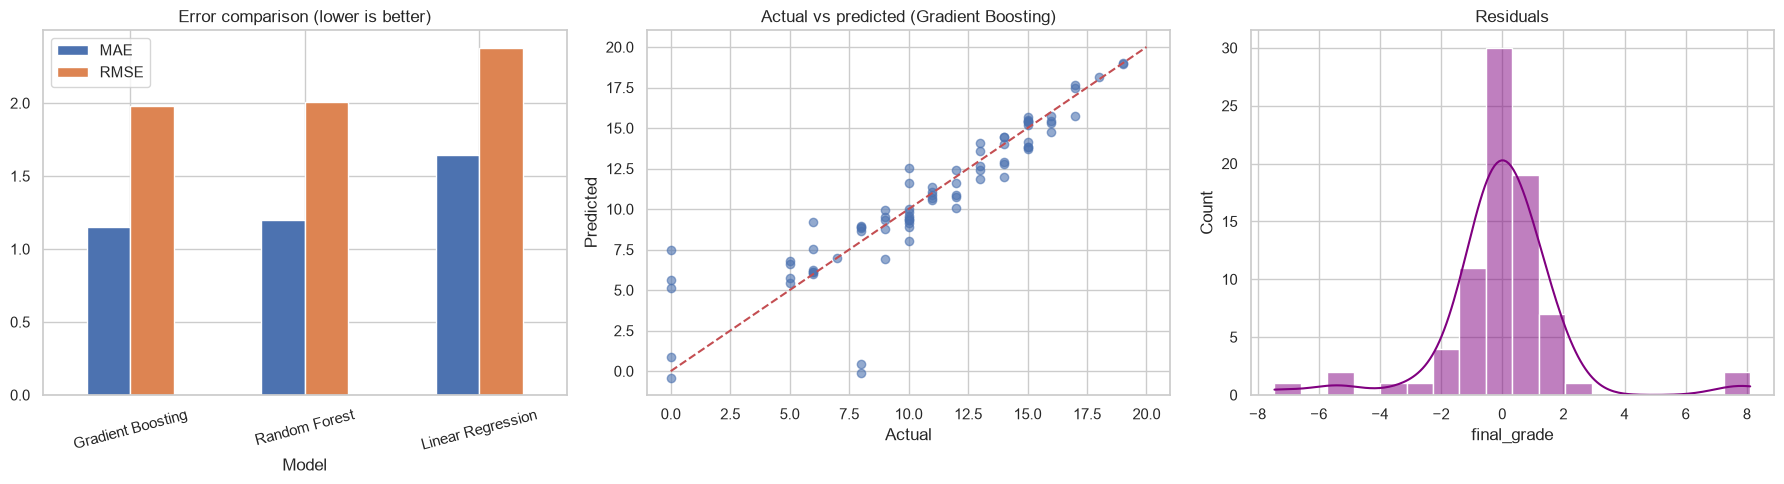

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", ax=axes[0], rot=15)
axes[0].set_title("Error comparison (lower is better)")

best_pred = best_regressor.predict(X_test)
axes[1].scatter(y_test, best_pred, alpha=0.6)
axes[1].plot([0, 20], [0, 20], "r--")
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Actual vs predicted ({best_model_name})")

sns.histplot(y_test - best_pred, kde=True, ax=axes[2], color="purple")
axes[2].set_title("Residuals")
plt.tight_layout()
plt.show()

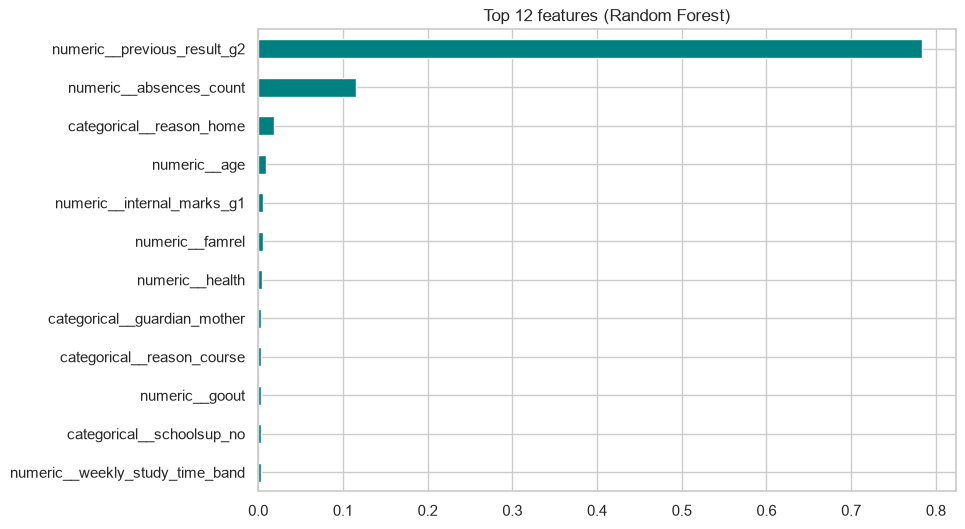

In [12]:
rf_pipe = trained_regressors["Random Forest"]
names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=names)
importances.sort_values().tail(12).plot(kind="barh", figsize=(9, 6), color="teal")
plt.title("Top 12 features (Random Forest)")
plt.show()

                      Model  Accuracy  Precision  Recall  F1-score
0       Logistic Regression     0.873      0.957   0.849       0.9
1  Random Forest Classifier     0.873      0.957   0.849       0.9
              precision    recall  f1-score   support

        Fail       0.75      0.92      0.83        26
        Pass       0.96      0.85      0.90        53

    accuracy                           0.87        79
   macro avg       0.85      0.89      0.86        79
weighted avg       0.89      0.87      0.88        79



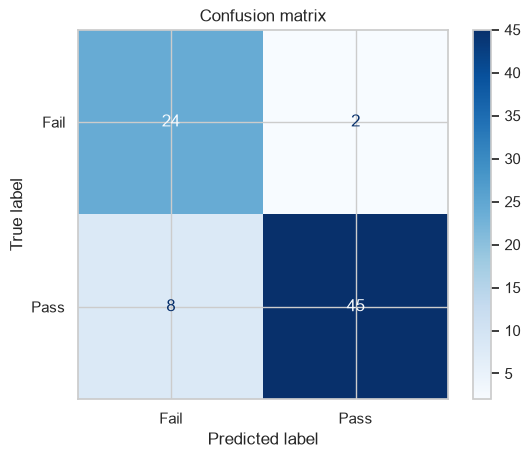

In [13]:
pass_label = (student_df["final_grade"] >= 10).astype(int)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_all, pass_label, test_size=0.2, random_state=RANDOM_STATE, stratify=pass_label)

classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest Classifier": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}
trained_classifiers, crow = {}, []
for name, estimator in classification_models.items():
    pipe = Pipeline([("prep", build_preprocessor()), ("model", estimator)])
    pipe.fit(Xc_train, yc_train)
    pred = pipe.predict(Xc_test)
    crow.append({"Model": name,
                 "Accuracy": accuracy_score(yc_test, pred),
                 "Precision": precision_score(yc_test, pred),
                 "Recall": recall_score(yc_test, pred),
                 "F1-score": f1_score(yc_test, pred)})
    trained_classifiers[name] = pipe

class_df = pd.DataFrame(crow).sort_values("F1-score", ascending=False).reset_index(drop=True)
print(class_df.round(3))
best_classifier = trained_classifiers[class_df.loc[0, "Model"]]

print(classification_report(yc_test, best_classifier.predict(Xc_test),
                            target_names=["Fail", "Pass"]))
ConfusionMatrixDisplay(confusion_matrix(yc_test, best_classifier.predict(Xc_test)),
                       display_labels=["Fail", "Pass"]).plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()

In [14]:
joblib.dump(best_regressor, "student_performance_regressor.joblib")
joblib.dump(best_classifier, "student_performance_classifier.joblib")

reg = joblib.load("student_performance_regressor.joblib")
clf = joblib.load("student_performance_classifier.joblib")
sample = X_test.iloc[[0]]
print("Predicted final grade:", round(float(reg.predict(sample)[0]), 2), "/ 20")
print("Actual final grade   :", y_test.iloc[0])
print("Predicted result     :", "Pass" if clf.predict(sample)[0] == 1 else "Fail")

Predicted final grade: 9.43 / 20
Actual final grade   : 10
Predicted result     : Fail


In [15]:
# Show predictions for the first 10 test students
sample_students = X_test.iloc[:10]
comparison = pd.DataFrame({
    "Actual grade": y_test.iloc[:10].values,
    "Predicted grade": reg.predict(sample_students).round(2),
    "Actual result": np.where(y_test.iloc[:10].values >= 10, "Pass", "Fail"),
    "Predicted result": np.where(clf.predict(sample_students) == 1, "Pass", "Fail"),
})
print(comparison)

   Actual grade  Predicted grade Actual result Predicted result
0            10             9.43          Pass             Fail
1            12            11.59          Pass             Pass
2             5             5.42          Fail             Fail
3            10             9.99          Pass             Fail
4             9             9.32          Fail             Fail
5            13            12.44          Pass             Pass
6            18            18.15          Pass             Pass
7             6             7.57          Fail             Fail
8             0             5.62          Fail             Pass
9            14            12.91          Pass             Pass


In [16]:
# Classification accuracy (Pass/Fail)
clf_pred = best_classifier.predict(Xc_test)
accuracy_pct = accuracy_score(yc_test, clf_pred) * 100
correct = (clf_pred == yc_test.values).sum()

# Regression performance
reg_pred = best_regressor.predict(X_test)
r2_pct = r2_score(y_test, reg_pred) * 100
within_1_mark_pct = (np.abs(y_test - reg_pred) <= 1).mean() * 100
within_2_marks_pct = (np.abs(y_test - reg_pred) <= 2).mean() * 100

print("=" * 55)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 55)
print(f"Classification model : {class_df.loc[0, 'Model']}")
print(f"Accuracy             : {accuracy_pct:.2f}%  ({correct} of {len(yc_test)} students correct)")
print(f"Precision            : {precision_score(yc_test, clf_pred) * 100:.2f}%")
print(f"Recall               : {recall_score(yc_test, clf_pred) * 100:.2f}%")
print(f"F1-score             : {f1_score(yc_test, clf_pred) * 100:.2f}%")
print("-" * 55)
print(f"Regression model     : {best_model_name}")
print(f"R2 score             : {r2_pct:.2f}%  (variation in grades explained)")
print(f"MAE                  : {mean_absolute_error(y_test, reg_pred):.2f} marks out of 20")
print(f"Predictions within ±1 mark : {within_1_mark_pct:.2f}%")
print(f"Predictions within ±2 marks: {within_2_marks_pct:.2f}%")
print("=" * 55)

FINAL MODEL PERFORMANCE SUMMARY
Classification model : Logistic Regression
Accuracy             : 87.34%  (69 of 79 students correct)
Precision            : 95.74%
Recall               : 84.91%
F1-score             : 90.00%
-------------------------------------------------------
Regression model     : Gradient Boosting
R2 score             : 80.84%  (variation in grades explained)
MAE                  : 1.15 marks out of 20
Predictions within ±1 mark : 65.82%
Predictions within ±2 marks: 88.61%
